<a href="https://colab.research.google.com/github/JeyasriHariharan/Global-Literacy-Educational-Trends./blob/main/literacy_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import os
os.listdir('/content')

['.config',
 'literate-and-illiterate-world-population.csv',
 'literacy.csv',
 'gdp-per-capita-worldbank.csv',
 'literacy-rates-vs-average-years-of-schooling.csv',
 'literacy-rate-of-young-men-and-women.csv',
 'sample_data']

# 📊 Global Literacy & Education Trends: An Analytical Study

## Objective
Analyze literacy, GDP, and schooling trends across countries.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [29]:
adult_lit = pd.read_csv('/content/literacy.csv')
youth_lit = pd.read_csv('/content/literacy-rate-of-young-men-and-women.csv')
illiteracy = pd.read_csv('/content/literate-and-illiterate-world-population.csv')
gdp = pd.read_csv('/content/gdp-per-capita-worldbank.csv')
schooling = pd.read_csv('/content/literacy-rates-vs-average-years-of-schooling.csv')

In [30]:
df_literacy = pd.merge(adult_lit, youth_lit, on=["entity","year"])
df_illiteracy = illiteracy.copy()
df_gdp_schooling = pd.merge(gdp, schooling, on=["entity","year"])

In [31]:
df_literacy = df_literacy.rename(columns={
'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99':'adult_literacy',
'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m':'youth_male',
'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f':'youth_female'
})

df_gdp_schooling = df_gdp_schooling.rename(columns={
'ny_gdp_pcap_pp_kd':'gdp_per_capita',
'mf_youth_and_adults__15_64_years__average_years_of_education':'avg_schooling_years'
})

In [32]:
df_literacy = df_literacy.dropna().drop_duplicates()
df_illiteracy = df_illiteracy.dropna().drop_duplicates()
df_gdp_schooling = df_gdp_schooling.dropna().drop_duplicates()

In [33]:
df_literacy = df_literacy[(df_literacy['year']>=1990)]
df_illiteracy = df_illiteracy[(df_illiteracy['year']>=1990)]
df_gdp_schooling = df_gdp_schooling[(df_gdp_schooling['year']>=1990)]

In [34]:
df_illiteracy['illiteracy_percent'] = 100 - df_illiteracy['literacy_rate']
df_literacy['gender_gap'] = df_literacy['youth_male'] - df_literacy['youth_female']
df_literacy['youth_avg'] = (df_literacy['youth_male'] + df_literacy['youth_female'])/2
df_gdp_schooling['gdp_per_schooling'] = df_gdp_schooling['gdp_per_capita'] / df_gdp_schooling['avg_schooling_years']
# Education Index
df_gdp_schooling['education_index'] = (
    df_gdp_schooling['avg_schooling_years'] * df_gdp_schooling['gdp_per_capita']
)

# Literacy Growth Rate
df_literacy['literacy_growth'] = df_literacy.groupby('entity')['adult_literacy'].pct_change()

df_literacy.head()

,entity,code_x,year,adult_literacy,code_y,youth_male,youth_female,owid_region,gender_gap,youth_avg,literacy_growth
1,Afghanistan,AFG,2011,31.00000,AFG,62.00000,32.00000,Asia,30.00000,47.000000,NaN
2,Afghanistan,AFG,2015,33.75384,AFG,57.73505,25.48416,Asia,32.25089,41.609605,0.088834
3,Afghanistan,AFG,2021,37.00000,AFG,71.00000,42.00000,Asia,29.00000,56.500000,0.096172
4,Albania,ALB,2001,99.00000,ALB,99.00000,99.00000,Europe,0.00000,99.000000,NaN
5,Albania,ALB,2008,96.00000,ALB,99.00000,99.00000,Europe,0.00000,99.000000,-0.030303


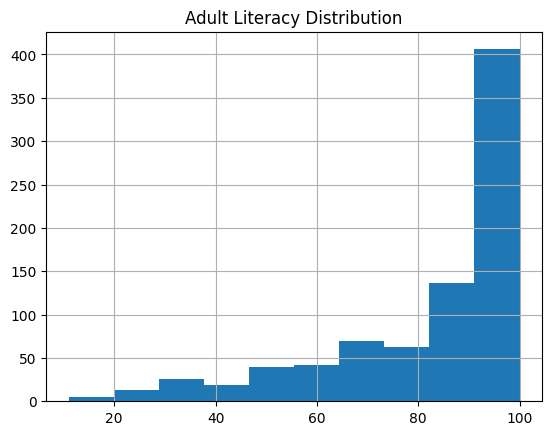

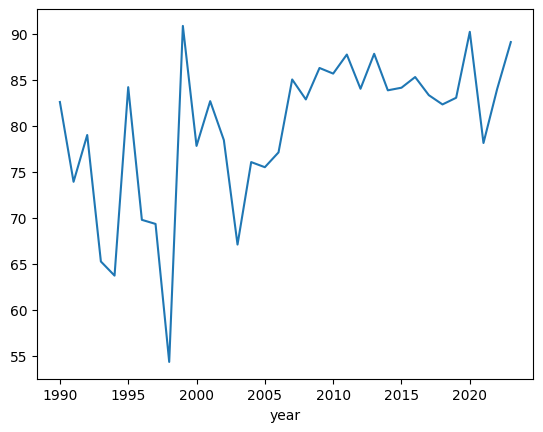

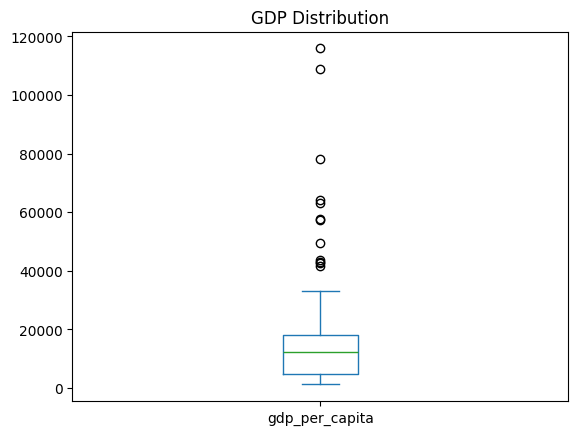

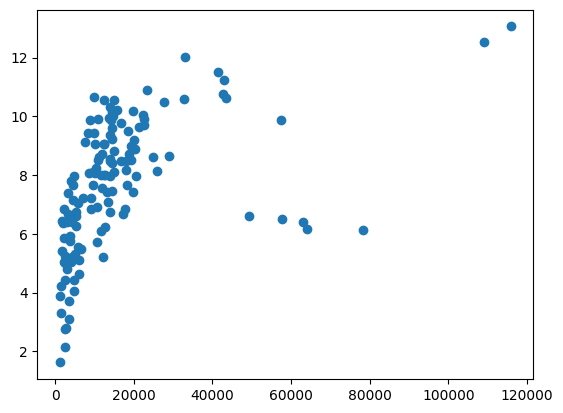

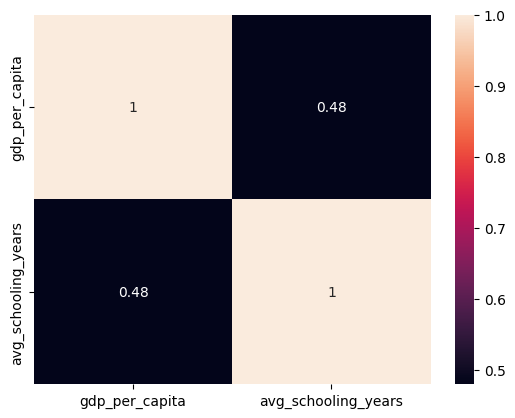

In [35]:
df_literacy['adult_literacy'].hist()
plt.title("Adult Literacy Distribution")
plt.show()
df_literacy.groupby('year')['adult_literacy'].mean().plot()
plt.show()


df_gdp_schooling['gdp_per_capita'].plot(kind='box')
plt.title("GDP Distribution")
plt.show()
plt.scatter(df_gdp_schooling['gdp_per_capita'], df_gdp_schooling['avg_schooling_years'])
plt.show()

sns.heatmap(df_gdp_schooling[['gdp_per_capita','avg_schooling_years']].corr(), annot=True)
plt.show()

Insights

- Literacy rate has improved over time  
- Higher GDP countries tend to have better education  
- There is a strong relationship between schooling and economic growth  
- Some countries still show disparities in literacy levels  

In [36]:
conn = sqlite3.connect(':memory:')
df_literacy.to_sql('literacy_rates',conn,index=False)
df_illiteracy.to_sql('illiteracy_population',conn,index=False)
df_gdp_schooling.to_sql('gdp_schooling',conn,index=False)

131

In [37]:
pd.read_sql_query("SELECT entity,adult_literacy FROM literacy_rates WHERE year=2020 ORDER BY adult_literacy DESC LIMIT 5",conn)

,entity,adult_literacy
0,Armenia,100.0
1,Mongolia,99.0
2,Spain,99.0
3,Palestine,98.0
4,Philippines,98.0


In [38]:
pd.read_sql_query("SELECT entity,youth_female FROM literacy_rates WHERE youth_female<80",conn)

,entity,youth_female
0,Afghanistan,32.00000
1,Afghanistan,25.48416
2,Afghanistan,42.00000
3,Angola,63.00000
4,Angola,71.00000
...,...,...
170,Yemen,35.00000
171,Zambia,66.00000
172,Zambia,66.00000
173,Zambia,66.00000


In [39]:
pd.read_sql_query("SELECT owid_region,AVG(adult_literacy) FROM literacy_rates GROUP BY owid_region",conn)

,owid_region,AVG(adult_literacy)
0,Africa,60.913878
1,Asia,87.146511
2,Europe,97.396630
3,North America,87.986129
4,Oceania,93.445866
5,South America,93.466994


In [40]:
pd.read_sql_query("SELECT entity,illiteracy_percent FROM illiteracy_population WHERE year=2000 AND illiteracy_percent>20",conn)

,entity,illiteracy_percent
0,Burundi,41.0
1,Cameroon,32.0
2,Central African Republic,49.0
3,Chad,74.0
4,Comoros,32.0
5,Cote d'Ivoire,51.0
6,Gambia,63.0
7,Ghana,42.0
8,Guinea-Bissau,59.0
9,Iraq,26.0


In [41]:
pd.read_sql_query("SELECT year,illiteracy_percent FROM illiteracy_population WHERE entity='India'",conn)

,year,illiteracy_percent
0,1991,52.0
1,2001,39.0
2,2006,37.0
3,2011,31.0
4,2022,24.0
5,2023,18.0


In [42]:
pd.read_sql_query("SELECT entity,illiteracy_percent FROM illiteracy_population ORDER BY illiteracy_percent DESC LIMIT 10",conn)

,entity,illiteracy_percent
0,Chad,89.0
1,Burkina Faso,87.0
2,Burkina Faso,86.0
3,Niger,86.0
4,Mali,81.0
5,Guinea,79.0
6,Burkina Faso,78.0
7,Burkina Faso,78.0
8,Chad,78.0
9,Burkina Faso,76.0


In [43]:
pd.read_sql_query("SELECT entity FROM gdp_schooling WHERE avg_schooling_years>7 AND gdp_per_capita<5000",conn)

,entity
0,China
1,Ghana
2,Philippines
3,Philippines
4,Zambia


In [44]:
pd.read_sql_query("SELECT entity,gdp_per_schooling FROM gdp_schooling WHERE year=2020 ORDER BY gdp_per_schooling DESC",conn)

,entity,gdp_per_schooling
0,Singapore,8873.892802
1,Kuwait,7458.129909
2,Saudi Arabia,5823.603854
3,Spain,3610.204170
4,Guyana,2257.526995
5,China,2137.391991
6,Mexico,1937.964833
7,Paraguay,1697.809740
8,Colombia,1555.049020
9,Mongolia,1480.134200


In [45]:
pd.read_sql_query("SELECT year,AVG(avg_schooling_years) FROM gdp_schooling GROUP BY year",conn)

,year,AVG(avg_schooling_years)
0,1990,6.583000
1,1995,8.105000
2,2000,6.237000
3,2005,7.559286
4,2010,8.166071
5,2015,7.665588
6,2020,8.738261


In [46]:
pd.read_sql_query("SELECT entity FROM gdp_schooling WHERE year=2020 AND avg_schooling_years<6 ORDER BY gdp_per_capita DESC LIMIT 10",conn)

,entity
0,Mauritania
1,Rwanda
2,Malawi
3,Mozambique


In [47]:
pd.read_sql_query("SELECT g.entity FROM gdp_schooling g JOIN illiteracy_population i ON g.entity=i.entity AND g.year=i.year WHERE avg_schooling_years>10 AND illiteracy_percent>20",conn)

,entity


In [48]:
pd.read_sql_query("SELECT l.year,l.adult_literacy,g.gdp_per_capita FROM literacy_rates l JOIN gdp_schooling g ON l.entity=g.entity AND l.year=g.year WHERE l.entity='India'",conn)

,year,adult_literacy,gdp_per_capita


In [49]:
pd.read_sql_query("SELECT l.entity,(youth_male-youth_female) FROM literacy_rates l JOIN gdp_schooling g ON l.entity=g.entity AND l.year=g.year WHERE g.gdp_per_capita>30000 AND l.year=2020",conn)

,entity,(youth_male-youth_female)
0,Kuwait,-1.0
1,Saudi Arabia,1.0
2,Singapore,0.0
3,Spain,-1.0
